# Data Mining  Project
## 1. Introduction
**Dataset Name:** Customer Personality Analysis  
**Source:** Kaggle (https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)

**Dataset Description:**
The dataset used in this project is the Marketing Campaign Dataset, which contains detailed information about customers and their interactions with a company’s marketing campaigns. The dataset includes 2240 customer records and multiple features describing personal characteristics, purchasing behavior, and campaign responses.
The features in the dataset can be categorized into:
Personal characteristics such as age (derived from Year_Birth), education level, and marital status.
Financial attributes such as customer income.
Behavioral attributes including spending on different product categories (e.g., wine, meat, fish, and sweets) and purchase channels (web, store, catalog).
Campaign-related attributes such as the number of accepted campaigns and the final response to a marketing campaign.

**Project Objective:** The goal of this project is to analyze customer data and apply data mining techniques, including clustering, fuzzy logic, and genetic algorithms, to extract insights and support decision-making.

**Domain Motivation:** This dataset belongs to the marketing domain, where understanding customer behavior is essential. Analyzing this data helps businesses identify customer segments, improve targeting strategies, and increase campaign effectiveness.



# **Install The Needed Libraries**

In [ ]:
!pip install numpy==1.26.4
!pip install scikit-learn==1.3.2
!pip install scikit-learn-extra==0.3.0

In [ ]:
!pip install scikit-learn-extra

In [ ]:
!pip install -q scikit-fuzzy

# Task 1: Exploratory Data Analysis & Visualization :

In this section, an exploratory data analysis is conducted to understand the structure and characteristics of the dataset. The goal is to identify patterns, and gain insights into the relationships between different features before applying preprocessing and modeling techniques.

**Import necessary libraries**

In [ ]:
import pandas as pd              # Data manipulation and analysis (DataFrames)
import numpy as np               # Numerical computations and array operations
import matplotlib.pyplot as plt  # Basic data visualization
import seaborn as sns            # Advanced statistical visualization
import random

import warnings
warnings.filterwarnings('ignore')  # Suppress unnecessary warnings

from scipy.cluster.hierarchy import dendrogram, linkage  # Hierarchical clustering and dendrogram visualization
from sklearn.cluster import AgglomerativeClustering      # Agglomerative (hierarchical) clustering algorithm
from sklearn.metrics import silhouette_score             # Clustering performance evaluation metric

from sklearn_extra.cluster import KMedoids               #Import K-Medoids clustering algorithm for clustering using actual data points as centers

import skfuzzy as fuzz                                   # Import skfuzzy library for fuzzy logic operations
from skfuzzy import control as ctrl                      # Import control module to build fuzzy inference systems




In [ ]:
# Uploading the csv file
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head(15)

In [ ]:
#dimensions of data
print("Dataset Shape:", df.shape)

Calculate Age and Total Spending for EDA purposes

We use 2026 as the current year based on project timing

In [ ]:
df['Age'] = 2026 - df['Year_Birth']

# Define the list of spending columns
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Calculate Total_Spending
df['Total_Spending'] = df[mnt_cols].sum(axis=1)

**The describe()function:**

summarizes the numerical data by showing key statistics like mean, min, max, and quartiles

In [ ]:
#describtion of the data
df.describe()

In [ ]:
#summary of the dataset
df.info()

In [ ]:
#data types of each columns
print(df.dtypes)

# **Visualization**:

Used to explore data patterns, distributions, and relationships, helping identify trends, outliers, and correlations.

**The histogram** illustrates the distribution of customer age in the dataset. It shows that most customers are concentrated within a specific age range, while a few extreme values appear at the edges, indicating possible outliers.
This visualization is useful for understanding the overall distribution of ages, identifying the most common age groups, and detecting anomalies that may require preprocessing.

In [ ]:
# VISUALIZATION 1: Histogram of Customer Age (Distributions)
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
print("Conclusion: The age distribution is roughly normal but shows a few extreme outliers (customers over 100 years old). The majority of the customer base falls between the ages of 40 and 70.")

**Bar Chart** :
Customer Education Levels
"This chart highlights that the majority of our customers are highly educated, primarily holding 'Graduation', PhD, or Master’s degrees.
Business Insight:
Given this academic profile, our marketing strategy should focus on professional, data-driven content. Aligning our communication style with this intellectually-oriented audience will enhance campaign effectiveness and foster deeper customer engagement."

In [ ]:
# VISUALIZATION 2: Bar Chart of Education Levels (Categorical Breakdown)
education_counts = df['Education'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(education_counts.index, education_counts.values, color='purple', alpha=0.7)
plt.title('Customer Count by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.show()
print("Conclusion: A significant majority of the customers hold a Graduation Bachelor's degree, followed by PhD and Master's. Highly educated individuals form the core customer base.")


**Scatter Plot:** Income vs. Total Spending Correlation
Observation: A strong positive correlation exists; as annual income rises, total spending on products increases significantly.
Data Distribution: Most customers earn between $20k and $80k, showing a consistent and predictable spending pattern.
Outlier Alert: An extreme outlier (Income > $600k) was identified, which must be removed to prevent skewed results in the clustering phase.
Business Value: High-income segments should be prioritized for premium marketing campaigns to maximize ROI.

In [ ]:
# VISUALIZATION 3: Scatter Plot of Income vs. Total Spending (Correlations)
plt.figure(figsize=(8, 5))
plt.scatter(df['Income'], df['Total_Spending'], color='blue', alpha=0.5)
plt.title('Income vs. Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.show()
print("Conclusion: There is a strong positive correlation between Income and Total Spending. As income increases, spending heavily increases. However, we can also spot an extreme outlier with an income over $600,000 that needs to be handled.")

**Pie Chart:** Marital Status Distribution
Technical Summary: A pie chart showing the distribution of top 5 marital categories using value_counts().

Findings:

Dominant Group: Married/Together represent 65% of customers.

Insight: Focus on family-oriented promotions for better engagement.

Implementation: Justifies using One-Hot Encoding in the final pipeline

In [ ]:
# VISUALIZATION 4: Pie Chart of Marital Status (Categorical Breakdown)
marital_counts = df['Marital_Status'].value_counts()
# Grouping some rare categories temporarily for a cleaner pie chart
plt.figure(figsize=(8, 8))
plt.pie(marital_counts.values[:5], labels=marital_counts.index[:5], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0'])
plt.title('Top 5 Marital Status Categories')
plt.show()
print("Conclusion: Married and Together (cohabiting) customers make up roughly 65% of the total base. Singles form the next largest group. This indicates that family-oriented promotions might be highly effective.")

**Bar Chart:** Campaign Response (Target Analysis)
Observation: The bar chart shows a significant class imbalance; the vast majority of customers (over 84%) did not accept the last campaign offer.

Key Insight: Mass marketing is currently inefficient, as only a small fraction of the total customer base responded positively.

Business Justification: This imbalance strongly justifies the need for Customer Clustering. By identifying specific segments, we can transition from mass outreach to targeted marketing, significantly improving response rates and reducing wasted effort

In [ ]:
# VISUALIZATION 5: Bar Chart of Campaign Response (Categorical Breakdown:Target Analysis)
plt.figure(figsize=(8, 5))
response_counts = df['Response'].value_counts()
plt.bar(['No', 'Yes'], response_counts.values, color=['#ff9999', '#66b3ff'], edgecolor='black')
plt.title("Customer Acceptance of the Last Campaign (Response)")
plt.xlabel("Accepted Campaign?")
plt.ylabel("Number of Customers")

plt.show()

print("conclusion: The bar chart reveals a significant class imbalance regarding the last marketing campaign. The vast majority of customers (over 84%) did not accept the offer No . Only a small fraction responded positively Yes . This highlights the inefficiency of mass marketing and strongly justifies our goal of using clustering to perform targeted marketing to increase this response rate.")

**The value_counts() function:** is used to calculate the frequency of each category within categorical features. It helps in understanding how data points are distributed across different values.
It was applied to features such as marital status, number of children at home, campaign response, and education level because these variables are categorical in nature and require frequency-based analysis rather than numerical statistics.

In [ ]:
# count frequency of each value in the feature
print(df['Marital_Status'].value_counts())
print("\n")
print(df['Kidhome'].value_counts())
print("\n")
print(df['Response'].value_counts())
print("\n")
# To see percentages (e.g., 0.50 instead of 1120)
print(df['Education'].value_counts(normalize=True) * 100)

In [ ]:
#count number of unique values in each column
df.nunique()

# **Task 2: Data Preprocessing :**

This step prepares the dataset for analysis by handling missing values, treating outliers, encoding categorical features, and scaling numerical data to ensure accurate and reliable modeling.


# **First: Data Cleaning**

# Handling Missing Values:
In this step, missing values in the dataset are identified and handled to ensure data quality and consistency. Missing data can negatively impact the performance of models and lead to inaccurate results.


---




In [ ]:
# Count missing values
df.isnull().sum()

In [ ]:
# Fill missing values in 'Income' with the median
df['Income'] = df['Income'].fillna(df['Income'].median())
print(df['Income'].head())

Missing values in the Income column (24 instances, approx. 1% of the data) were imputed using the median value. This approach was preferred over dropping rows to preserve the dataset size, and the median was chosen specifically because it is robust against outliers, ensuring that extreme income values do not skew the distribution.

## Dealing with duplicates:

Duplicates can bias the analysis and affect model performance by giving more weight to repeated observations.
Therefore, detecting and removing duplicate entries ensures that each record represents a unique customer.

In [ ]:
# printing the num of duplicates
print(df.duplicated().sum())

No duplicate rows were found in the dataset. However, if duplicates had been present, they would have been removed to prevent redundancy and ensure the accuracy of the analysis

''df.drop_duplicates(inplace=True) ''

## Converting Datatypes:

This step ensures each feature has the correct data type (e.g., numeric or categorical) to enable proper analysis and model processing.

In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

The Dt_Customer column was converted to datetime format to enable time-based analysis.

# **Handling outliers**

Outliers are extreme values that differ significantly from other observations in the dataset. These values can negatively impact data mining algorithms, especially clustering methods, as they distort distance calculations and lead to misleading groupings.

**Detection Method**

Outliers were detected using the Interquartile Range (IQR) method and visualized using boxplots.

The IQR is calculated as the difference between the third quartile (Q3) and the first quartile (Q1). Any data point lying below (Q1 − 1.5 × IQR) or above (Q3 + 1.5 × IQR) is considered an outlier.

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # filtering instead of modifying directly
    df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df_clean

The **boxplot** shows the distribution of income and helps detect outliers, which can affect analysis and model performance.

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['Income'].dropna())
plt.title('Boxplot of Customer Income')
plt.ylabel('Income')
plt.show()
print("Conclusion: The boxplot clearly highlights a severe outlier in the Income feature (above 600k). It also shows a few other high-income outliers. These must be removed during preprocessing to ensure clustering algorithms perform correctly.")

In [ ]:
# Apply on Income
df = remove_outliers(df, 'Income')

# Apply on Age
df = remove_outliers(df, 'Age')

Removing **outliers** improves the reliability of clustering algorithms, as they are sensitive to distance measures. By eliminating extreme values, more meaningful and well-separated clusters can be obtained.

In [ ]:
#Boxplot after removing the outliers
plt.figure(figsize=(8, 5))
plt.boxplot(df['Income'])
plt.title('Boxplot of Customer Income (After Cleaning)')
plt.ylabel('Income')
plt.show()
#The effectiveness of the outlier removal process was confirmed

## Feature Engineering

In this step, new features were created from existing data to improve the quality of analysis and provide more meaningful insights.

In [ ]:
# Combine fields to reduce noise
df['Children'] = df['Kidhome'] + df['Teenhome']
df['Is_Parent'] = np.where(df['Children'] > 0, 1, 0)

reference_date = df['Dt_Customer'].max()
df['Customer_Days'] = (reference_date - df['Dt_Customer']).dt.days

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']

# Calculate Total_Spending before dropping the original columns
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[mnt_cols].sum(axis=1)

Family Status **(Children & Is_Parent)**: Combined Kidhome and Teenhome into a total count and a binary indicator. This simplifies the household structure into a single meaningful metric for family-based targeting.

Customer Tenure **(Customer_Days)**: Calculated the number of days since enrollment relative to the latest date in the dataset. This measures loyalty and tenure, which are critical factors for understanding long-term purchasing behavior.

Total Expenditure **(Total_Spending)**: Aggregated spending across all product categories (Wines, Fruits, Meat, etc.) into a single feature to represent the overall financial value of each customer.

##  Removing Unnecessary data

In this step, unnecessary and redundant features were removed from the dataset to simplify the analysis and reduce noise. Columns such as identifiers, constant values, and less informative features were dropped, along with features that were already combined into new variables (e.g., spending and children-related features).
This helps improve model performance and makes the dataset more efficient for further processing.

In [ ]:
df.drop(['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Dt_Customer','AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5','MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds','Kidhome','Teenhome'],
        axis=1, inplace=True, errors='ignore')

print(df.columns)

## Data Standardization
In this step, we normalize the text data in the **Education** and **Marital_Status** columns.
This involves:
* **Removing leading/trailing spaces** using `.strip()`.
* **Converting all text to uppercase** using `.upper()` to ensure consistency.
* **Verifying the results** by inspecting unique values.

In [ ]:
# Clean Education column
df['Education'] = df['Education'].str.strip().str.upper()

# Clean Marital Status column
df['Marital_Status'] = df['Marital_Status'].str.strip().str.upper()

# Check values after cleaning
print("Education unique values:")
print(df['Education'].unique())

print("\nMarital Status unique values:")
print(df['Marital_Status'].unique())

# Data Tranformation

## Encoding Categorical Variables



**Since most data mining algorithms require numerical input, categorical features were converted into numerical representations using appropriate encoding techniques**

## Label Encoding: Education
Since the **Education** levels have a natural rank (e.g., a PhD is higher than a Master's), we apply **Label Encoding**. We map each category to a numerical value to preserve this order for the model.

In [ ]:
education_map = {
    'BASIC': 0,
    '2N CYCLE': 1,
    'GRADUATION': 2,
    'MASTER': 3,
    'PHD': 4
}

df['Education'] = df['Education'].map(education_map)

print("Missing values in Education after encoding:")
print(df['Education'].isnull().sum())


**The Education feature** was encoded using label encoding because it has a natural order (from Basic to PhD). Assigning numerical values preserves this ranking and allows the model to interpret educational levels meaningfully.

In [ ]:
print(df['Education'].head(10))

## 4. One-Hot Encoding: Marital Status
Unlike Education, **Marital Status** is a nominal variable with no inherent order. We apply **One-Hot Encoding** using `pd.get_dummies()` to create separate binary columns for each status. This allows the model to treat each category independently without assuming a numerical hierarchy.

**The Marital_Status feature** was encoded using One-Hot Encoding, as it represents nominal categories with no inherent order. This method creates separate binary columns for each category, preventing the model from assuming any false relationship between them.

In [ ]:
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital')

print("\nNew columns after One-Hot Encoding:")
print([col for col in df.columns if 'Marital' in col])


## 5. Verification of Encoded Features
To ensure the encoding process was successful, we perform a final check on the data structure. This includes:
* **Shape Analysis:** Confirming the addition of new One-Hot encoded columns.
* **Feature Inspection:** Viewing the transformed `Education` (Ordinal) and `Marital_Status` (One-Hot) features.
* **Distribution Check:** Verifying that the ordinal mapping for Education correctly represents all original categories.

In [ ]:
print("Current shape of the dataset:", df.shape)
print("\nFirst 5 rows showing encoded features:")
display(df[['Education'] + [col for col in df.columns if 'Marital' in col]].head())

print("\nUpdated list of columns:")
print(df.columns.tolist())

print("\nEducation encoding levels distribution:")
print(df['Education'].value_counts().sort_index())

# StandardScaler


Feature scaling was applied to **normalize the numerical features** using **Standardization** (Z-score normalization). This technique transforms the data so that it has mean = 0 و standard deviation = 1.

 This step is essential for distance-based algorithms such as clustering, ensuring that all features contribute equally to the model without being dominated by large-scale variables.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Remove target FIRST
df_model = df.drop('Response', axis=1)

# 2. Columns to scale (continuous only)
cols_to_scale = ['Income', 'Recency', 'Age', 'Total_Spending',
                 'Customer_Days', 'NumDealsPurchases', 'NumWebPurchases',
                 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

# 3. Create scaler
scaler = StandardScaler()

# 4. Apply scaling
df_scaled = df_model.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_model[cols_to_scale])

# 5. Convert True/False to 0/1
df_scaled = df_scaled.replace({True: 1, False: 0})

# 6. Check
print("Scaling Done ")
print(df_scaled.head())

In [ ]:
# Ensure scaling was done right
df.isnull().sum()

In [ ]:
print("Final check for Education levels:\n", df['Education'].value_counts().sort_index())

## 6. Dimensionality Reduction (PCA)
To optimize the dataset for modeling, we apply **Principal Component Analysis (PCA)**. Instead of choosing a fixed number of components, we set the algorithm to retain **90% of the total variance**. This ensures we reduce the dimensionality significantly while preserving the vast majority of the underlying information.

**Key Objectives:**
* **Efficiency:** Reduce the number of features to improve model training speed.
* **Noise Reduction:** Filter out less significant variations in the data.
* **Information Preservation:** Maintain at least 91.61% of the original dataset's variance.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)

pca_data = pca.fit_transform(df_scaled)

# Create DataFrame
df_final_pca = pd.DataFrame(pca_data)

# Rename columns
df_final_pca.columns = [f'PC{i+1}' for i in range(df_final_pca.shape[1])]

# Variance
explained_variance = sum(pca.explained_variance_ratio_) * 100

# Output
print("PCA RESULTS : ")
print("Original Features:", df_scaled.shape[1])
print("Reduced Features:", df_final_pca.shape[1])
print(f"Explained Variance: {explained_variance:.2f}%")

print(df_final_pca.head())

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.grid()
plt.show()

#Task 6: Genetic Algorithm
Genetic Algorithm is used to improve clustering by evolving better solutions over time using a fitness function.


In this step, a clean version of the dataset is prepared for the Genetic Algorithm.
- First, a copy of the scaled data is created to ensure consistency.
- Then, irrelevant and less useful features (such as certain marital categories and complaint indicators) are removed to reduce noise and avoid bias.



In [ ]:
df_ga = df_scaled.copy()

# Exclude unwanted features
exclude_features = [
    'Marital_ABSURD',
    'Marital_ALONE',
    'Marital_DIVORCED',
    'Marital_MARRIED',
    'Marital_SINGLE',
    'Marital_TOGETHER',
    'Marital_WIDOW',
    'Marital_YOLO',
    'Complain'
]

df_ga = df_ga.drop(columns=exclude_features, errors='ignore')

# remove leakage
df_clean = df_ga.copy()

features = list(df_clean.columns)
num_features = len(features)

This section defines the main parameters used to run the Genetic Algorithm:

- **Population Size (20):** number of candidate solutions in each generation.

- **Generations (30):** how many iterations the algorithm runs to improve solutions.

- **Mutation Rate (0.1):** probability of random changes to maintain diversity.

- **Number of Clusters (3):** fixed number of clusters used in the model.
Random seeds are set to ensure reproducible results.
fitness_history and avg_history are used to track performance over generations.

In [ ]:
# Initialization of Genetic Parameters

POPULATION_SIZE = 20
GENERATIONS     = 30
MUTATION_RATE   = 0.1
N_CLUSTERS      = 3

random.seed(42)
np.random.seed(42)

fitness_history = []
avg_history = []


###Fitness Function
- **Objective:** Evaluates how "good" a feature subset is.
- **Mechanism:** It trains a K-Medoids model on the selected features and returns the Silhouette Score.
- **Penalty Logic:** A 'Smart Penalty' is applied to favor subsets with 3–6 features, ensuring a balance between model complexity and interpretability.

In [ ]:
# Fitness Function

def calculate_fitness(individual):
    selected = [i for i, bit in enumerate(individual) if bit == 1]


    if len(selected) < 2:
        return 0

    data = df_clean.iloc[:, selected]

    try:
        model = KMedoids(n_clusters=N_CLUSTERS, random_state=42)
        labels = model.fit_predict(data)

        if len(set(labels)) < N_CLUSTERS:
            return 0

        score = silhouette_score(data, labels)


        if len(selected) < 3:
            score *= 0.7
        elif 3 <= len(selected) <= 6:
            score *= 1.0   # perfect range
        else:
            score *= 0.85

        return score

    except:
        return 0

This function creates a single individual (solution) for the Genetic Algorithm.

- Each individual is a list of 0s and 1s representing feature selection.

- 1 means the feature is selected, 0 means it is not.

- It ensures that at least two features are selected to keep the solution valid.

- If this condition is not met, it randomly turns on more features until it is satisfied.

In [ ]:
# Create Individual

def create_individual():
    ind = [random.randint(0, 1) for _ in range(num_features)]
    while sum(ind) < 2:
        ind[random.randint(0, num_features - 1)] = 1
    return ind

In this phase, we use Tournament Selection to decide which "chromosomes" (feature sets) get to reproduce.

- **How it works:** We pull a random "scout group" from the population and let them compete. The one with the best fitness score wins the right to be a parent.

- **The Goal:** It’s all about balance. It gives our best solutions a clear advantage (Exploitation) but, because the groups are chosen randomly, it still allows "underdog" traits to survive (Exploration).

- **Why this matters:** This keeps our population diverse and prevents the algorithm from settling for a "good" solution too early when a "great" one is still out there.

In [ ]:
# Selection

def tournament_select(population, fitness_values, k=3):
    idx = random.sample(range(len(population)), k)
    best = max(idx, key=lambda i: fitness_values[i])
    return population[best]

- The initial population is randomly generated, where each individual represents a subset of features.

- The fitness of each individual is evaluated using the fitness function.

- The best individual is selected as the baseline solution.

- This baseline is used to track improvements across generations.

- The number of selected features in the baseline solution is also recorded.

In [ ]:
# Initial Population

population = [create_individual() for _ in range(POPULATION_SIZE)]
initial_fitness = [calculate_fitness(ind) for ind in population]

baseline_score = max(initial_fitness)
baseline_individual = population[np.argmax(initial_fitness)]

print(f"Baseline Score: {baseline_score:.4f}")
print(f"Baseline Features Count: {sum(baseline_individual)}")


The Steps in the GA Loop

- **Fitness Evaluation:** Calculates the performance (fitness_values) of each individual (chromosome) in the current population using a fitness function.

- **Performance Tracking:** Identifies the best-performing individual and records both the Best and Average fitness to monitor progress over time.

- **Elitism:** Automatically carries over the single best individual (best_idx) to the next generation to ensure the algorithm never loses its best discovered solution.

- **Parent Selection:** Uses Tournament Selection to pick two parents (p1, p2), favoring individuals with higher fitness while maintaining genetic diversity.

- **Crossover (Recombination):** Creates a child by performing a Single-Point Crossover, combining the first part of one parent with the second part of the other.

- **Mutation:** Randomly flips bits (0 to 1 or 1 to 0) in the child's genetic code based on a MUTATION_RATE to introduce new traits and prevent premature convergence.

- **Constraint Handling:** Includes a safety loop (sum(child) < 2) ensuring each solution selects at least two features, preventing empty or invalid models.

- **Population Update:** Replaces the old population with the new_population and repeats the process for the specified number of GENERATIONS.

In [ ]:
# GA Loop

for gen in range(GENERATIONS):
    fitness_values = [calculate_fitness(ind) for ind in population]

    best_idx = np.argmax(fitness_values)
    best_fit = fitness_values[best_idx]
    avg_fit = np.mean(fitness_values)

    fitness_history.append(best_fit)
    avg_history.append(avg_fit)

    # Elitism
    new_population = [population[best_idx][:]]

    while len(new_population) < POPULATION_SIZE:
        p1 = tournament_select(population, fitness_values)
        p2 = tournament_select(population, fitness_values)

        point = random.randint(1, num_features - 1)
        child = p1[:point] + p2[point:]

        # Mutation
        for i in range(num_features):
            if random.random() < MUTATION_RATE:
                child[i] = 1 - child[i]

        while sum(child) < 2:
            child[random.randint(0, num_features - 1)] = 1

        new_population.append(child)

    population = new_population
    print(f"Gen {gen+1:2d}: Best={best_fit:.4f} | Avg={avg_fit:.4f}")

Final Result

**Final Evaluation:** Performs a final calculation of fitness scores for the entire population to ensure you are working with the most up-to-date performance data.

**Best Individual Identification:** Locates the single individual (best_individual) with the highest score (best_score) in the final generation.

**Genotype to Phenotype Mapping:** Converts the binary representation (the "chromosome" of 0s and 1s) into actual feature names:

**Index Extraction:** Identifies the positions (i) where the bit is set to 1.

**Feature Retrieval:** Matches those indices back to the original features list.

**Performance Metrics:** Outputs the final results, specifically the optimal feature subset, the maximum fitness score achieved, and the total count of selected features.

In [ ]:
# Final Result

final_fitness = [calculate_fitness(ind) for ind in population]
best_idx = np.argmax(final_fitness)
best_individual = population[best_idx]
best_score = final_fitness[best_idx]

best_features_idx = [i for i, b in enumerate(best_individual) if
b == 1]
best_features = [features[i] for i in best_features_idx]

print("\n=== BEST SOLUTION ===")
print("Selected Features :", best_features)
print(f"GA Best Score     : {best_score:.4f}")
print(f"Number of Features: {len(best_features)}")


The Final Model

After letting the Genetic Algorithm evolve to find the most influential features, we put them to work. We use the K-Medoids algorithm on this optimized subset to group our customers into distinct, meaningful segments.

- **The Strategy:** By focusing only on the "Best Features" identified by our GA, we strip away the noise and let the strongest patterns drive the clustering.

- **The Metric (Silhouette Score):** This score tells us how well-defined our segments are. A higher score means our customers are very similar to those in their own group and distinctly different from those in others.

- **The Result:** These labels aren't just numbers; they are the foundation for our targeted marketing strategy.

In [ ]:
# Final Clustering

ga_data = df_clean.iloc[:, best_features_idx]

model = KMedoids(n_clusters=N_CLUSTERS, random_state=42)
ga_labels = model.fit_predict(ga_data)

final_sil = silhouette_score(ga_data, ga_labels)
print(f"Final Silhouette: {final_sil:.4f}")


**Plot 1:** Fitness Evolution

This plot shows how the fitness (silhouette score) improves over generations. The best fitness increases over time, indicating that the Genetic Algorithm is successfully finding better feature subsets.

In [ ]:
# Plot 1: Fitness Evolution

plt.figure(figsize=(10, 5))
plt.plot(fitness_history, label="Best Fitness", linewidth=2)
plt.plot(avg_history, label="Average Fitness", linewidth=2, linestyle="--")
plt.axhline(y=baseline_score, linestyle=":", linewidth=2, label=f"Baseline ({baseline_score:.4f})")
plt.xlabel("Generation")
plt.ylabel("Silhouette Score")
plt.title("GA Fitness Evolution over Generations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Baseline vs GA Clustering Comparison

baseline_idx = [i for i, b in enumerate(baseline_individual) if b == 1]

baseline_data = df_clean.iloc[:, baseline_idx]
ga_data = df_clean.iloc[:, best_features_idx]

baseline_model = KMedoids(n_clusters=N_CLUSTERS, random_state=42)
baseline_labels = baseline_model.fit_predict(baseline_data)
sil_baseline = silhouette_score(baseline_data, baseline_labels)

ga_model = KMedoids(n_clusters=N_CLUSTERS, random_state=42)
ga_labels = ga_model.fit_predict(ga_data)
sil_ga = silhouette_score(ga_data, ga_labels)

**Plot 2:** Scatter Comparison

This plot compares clustering before and after applying the Genetic Algorithm. The GA-optimized clustering shows clearer separation between clusters and better grouping of customers.

In [ ]:
# Plot 2: Scatter Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Income'], df['Total_Spending'], c=baseline_labels, cmap='Set1', alpha=0.6)
axes[0].set_title(f'Baseline (Initial Population)\nScore={sil_baseline:.3f} | {sum(baseline_individual)} features')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Spending')

axes[1].scatter(df['Income'], df['Total_Spending'], c=ga_labels, cmap='Set1', alpha=0.6)
axes[1].set_title(f'GA Optimized\nScore={sil_ga:.3f} | {len(best_features)} features')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Total Spending')

plt.suptitle('Baseline vs GA Optimized Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Plot 3:** Bar Chart

This chart compares the silhouette scores of the baseline and GA-optimized models. The GA approach achieves a higher score, indicating improved clustering performance.

In [ ]:
# Plot 3: Bar Chart

methods = ['Baseline\n(Initial Pop)', 'GA Optimized']
scores = [sil_baseline, sil_ga]

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, scores, edgecolor='black', width=0.4)
plt.ylabel('Silhouette Score')
plt.title('Baseline vs GA Optimized')
plt.ylim(0, max(scores) * 1.2)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Plot 4:** Cluster Sizes

This plot shows the distribution of customers across clusters. It helps understand the balance of segments and identify the dominant customer group.

In [ ]:
# Assign Final Clusters + Profile

df['Cluster_GA'] = ga_labels

profile_cols = ['Income', 'Total_Spending', 'Age', 'Children', 'Customer_Days']
profile_cols = [c for c in profile_cols if c in df.columns]

print("\n=== CLUSTER PROFILE ===")
print(df.groupby('Cluster_GA')[profile_cols].mean().round(2))

print("\n=== CLUSTER SIZES ===")
print(df['Cluster_GA'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
df['Cluster_GA'].value_counts().sort_index().plot(kind='bar')
plt.title('Cluster Sizes - GA Optimized')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Task 3: K-Medoid Clustering

 It refers to applying a robust clustering algorithm that partitions the dataset into meaningful groups by selecting actual data points as cluster centers (medoids), aiming to minimize dissimilarity within each cluster and identify natural patterns in the data




**Why K-Medoids over K-Means?**


 - Medoids are REAL customer records, more interpretable.

 - Robust to outliers in Income and Spending.
  
 - Each cluster has a concrete "representative customer".

In [ ]:
# Select GA Features

selected_features = best_features  # ['NumWebPurchases', 'Total_Spending', 'Is_Parent']

X_selected = df_scaled[selected_features].values

# Initialize

k_values = range(2, 10)
silhouette_scores = []
inertia_values = []


**Model Configuration**

**Feature Selection:** Utilizing the optimized features identified by the Genetic Algorithm (GA) to ensure clustering is based on the most impactful variables.

**Initialization:** Setting up parameters for testing different cluster counts (K from 2 to 9) to determine the optimal structure.

In [ ]:
# Elbow + Silhouette

for k in k_values:
    kmedoids = KMedoids(n_clusters=k, metric='manhattan', random_state=42)
    labels = kmedoids.fit_predict(X_selected)

    unique_labels = len(set(labels))

    if unique_labels > 1:
        silhouette = silhouette_score(X_selected, labels, metric='manhattan')
    else:
        silhouette = -1  # avoid error if only 1 cluster

    silhouette_scores.append(silhouette)
    inertia_values.append(kmedoids.inertia_)

    print(f"k={k}, Clusters={unique_labels}, Silhouette={silhouette:.4f}")

**Finding Optimal 'K'**:

**Iterative Testing:** We run the K-Medoids algorithm for each 'K' value.

**Evaluation Metrics:**

- Inertia: Measures how compact the clusters are (lower is better).
Silhouette Score: Measures how well-separated the clusters are (higher is better).

- Automation: The code automatically identifies the 'Best K' by maximizing the silhouette score.

In [ ]:
#  Elbow Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_values, marker='o', color='#1f77b4', linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — K-Medoids (Manhattan)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This plot is used to determine the optimal number of clusters (K) using the Elbow Method with K-Medoids (Manhattan distance).

The graph shows the relationship between the number of clusters (k_values) and Inertia, which measures how well the data points fit within their assigned clusters.
As K increases, inertia usually decreases because clusters become smaller and more specific.
The "elbow point" is the value of K where the decrease in inertia starts to slow down significantly.
This point is considered the best balance between model simplicity and clustering quality.

Summary: we choose the K at the elbow because it gives good clustering without unnecessary complexity.

In [ ]:
#  Silhouette Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score — K-Medoids (Manhattan)")
plt.grid(True)
plt.show()

This plot evaluates the quality of clustering for different values of K using the Silhouette Score.


The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters.
Its value ranges from -1 to 1:
- Close to 1: clusters are well separated and clearly defined.
- Around 0: clusters are overlapping.
- Negative values : points may be assigned to the wrong cluster.
The graph shows how the Silhouette Score changes as the number of clusters (K) increases.


The best K is usually the one with the highest Silhouette Score, as it indicates the most meaningful separation between clusters.


Summary: this plot helps validate whether the chosen number of clusters is truly good or not, beyond just inertia-based evaluation

In [ ]:
#  Best K
optimal_k = list(k_values)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K: {optimal_k}")

#  Final Model
kmedoids_final = KMedoids(n_clusters=optimal_k, metric='manhattan', random_state=42)
clusters = kmedoids_final.fit_predict(X_selected)

print(f"Silhouette Score (k={optimal_k}): {silhouette_score(X_selected, clusters, metric='manhattan'):.4f}")

#  Save Clusters
df['Cluster'] = clusters          # original data for interpretation

- Best K Selection: The optimal number of clusters is chosen as the K with the highest Silhouette Score, since it indicates the best cluster separation.

- Final Model: A K-Medoids model is trained using the selected optimal K, and a final Silhouette Score is calculated to confirm clustering quality.
- Saving Results: The assigned cluster labels are added to the original dataset in a new column called Cluster for further analysis and interpretation.

Summary: we pick the best K, build the final model, then label the data for analysis.

In [ ]:
#  Cluster Sizes
print("\n=== Cluster Sizes ===")
print(df['Cluster'].value_counts().sort_index())

 To check the size and balance of each segment.

 This ensures we don't have extremely tiny clusters that lack statistical significance, allowing us to understand how our customer base is distributed across the segments.

In [ ]:
#  Cluster Profiles
profile_cols = [
    'Income', 'Total_Spending', 'Age', 'Children',
    'Recency', 'Customer_Days',
    'NumStorePurchases', 'NumCatalogPurchases',
    'NumWebPurchases'
]

print("\n=== Cluster Profiles ===")
cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(2)
print(cluster_profile)

To calculate the average behavior of each segment.

By aggregating features (Income, Spending, Web/Store activity) per cluster, we can assign a meaningful business persona to each group (e.g., "High-spending Digital Shoppers" vs. "Budget-conscious Families").

In [ ]:
#  Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending',
    hue='Cluster',
    palette='viridis',
    s=80,
    alpha=0.6
)

# Medoids
medoid_indices = kmedoids_final.medoid_indices_
medoid_points = df.iloc[medoid_indices]

plt.scatter(
    medoid_points['Income'],
    medoid_points['Total_Spending'],
    c='red',
    marker='*',
    s=300,
    label='Medoids'
)

plt.title('Customer Segments: Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend()
plt.grid(True)
plt.show()

The **plot** shows customer segmentation based on Income and Total Spending, where each color represents a different cluster created by K-Medoids.


Each point is a customer, grouped by similarity.


Red stars represent the medoids, which are the most representative customers in each cluster.


Summary: the chart visualizes how customers are divided into meaningful groups based on their income and spending behavior.

In [ ]:
# Bar Chart

means = df.groupby('Cluster')['Total_Spending'].mean()

plt.figure(figsize=(6,4))
plt.bar(means.index, means.values)
plt.title('Average Spending per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Mean Spending')
plt.show()

To visually compare the financial performance of each segment.

This bar chart highlights the clear differences in "Total Spending" between clusters, making it easy to identify which segment contributes the most to company revenue and which segments may require more engagement.

In [ ]:
radar_cols = [c for c in [
    'Income', 'Total_Spending', 'Age',
    'NumStorePurchases', 'NumCatalogPurchases',
    'NumWebPurchases'
] if c in df.columns]

profile_r = cluster_profile[radar_cols]

#normalize
profile_r_norm = (profile_r - profile_r.min()) / (profile_r.max() - profile_r.min())

N = len(radar_cols)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['pink', 'lightblue', 'lightgreen']
markers = ['o', 's', '^']

for i, cluster in enumerate(profile_r_norm.index):
    values = profile_r_norm.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2.5, label=f'Cluster {cluster}',
            color=colors[i], marker=markers[i], markersize=7)
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_cols, fontsize=11)
ax.set_title('Cluster Profiles Radar', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

This radar chart compares different customer clusters across key features like income, spending, age, and purchase behavior.


Data is normalized for fair comparison.


Each line represents a cluster showing its overall behavior pattern.


Key Insight
It highlights how customer groups differ in income, spending, and buying habits across channels.

It gives a quick visual comparison of customer segments and their behavioral differences.

In [ ]:
for c in sorted(df['Cluster_GA'].unique()):
    print(f"\n===== Cluster {c} =====")
    display(df[df['Cluster_GA'] == c].describe())

This code generates summary statistics for each cluster created by the Genetic Algorithm.

It loops through all clusters and displays key statistics for each one.

These statistics include averages, minimums, and maximum values of features.

It helps compare clusters by showing their main numerical characteristics and differences.






**Cluster Profiles and Interpretation**

- Cluster 0 -> Budget-Conscious Families:
This segment consists of customers with lower income levels and minimal spending. They typically have more children at home, indicating that their budget is split among more family members, leading to highly selective purchasing behavior.

- Cluster 1 -> Active Middle Class:
This group represents middle-income customers with moderate spending habits. They are the primary drivers of digital sales, showing the highest engagement with Web Purchases. This segment values convenience and online accessibility.

- Cluster 2 -> High-Value Traditionalists:
A high-income segment characterized by the highest total expenditure. These customers are mostly childless and prefer traditional shopping channels like catalogs and physical stores. They represent the most profitable segment due to their high purchasing power.

## **Task 4: Hierarchical Clustering**
We apply Hierarchical Clustering to identify distinct customer segments. To ensure the highest quality of segmentation, we are using the  feature set identified by the Genetic Algorithm (GA): Total Spending, Number of Web Purchases, and Parenthood Status (Is_Parent).
This selection allows us to segment customers based on three critical dimensions: Financial Capacity, Digital Behavior, and Family Commitments.


**Our Roadmap:**

*   Visualize the hierarchical structure using Dendrograms for Single, Complete, and Average linkage methods.
*   Determine the optimal number of clusters (K) using the Elbow Method and Silhouette Score.

*   Select the most balanced configuration as our final model at least 10%.

In [ ]:
# 1. Feature Selection (Optimal features from GA)
features_to_use = ['NumWebPurchases', 'Total_Spending', 'Is_Parent']
df_subset = df_scaled[features_to_use].copy()

for col in features_to_use:
    upper_limit = df_subset[col].quantile(0.99)
    df_subset[col] = df_subset[col].clip(upper=upper_limit)

# 2. Create Dendrograms
linkage_methods = ['single', 'complete', 'average']
for method in linkage_methods:
    plt.figure(figsize=(10, 5))
    linked = linkage(df_subset, method=method)
    dendrogram(linked, truncate_mode='lastp', p=12, leaf_rotation=90., leaf_font_size=10.)
    plt.title(f'Dendrogram ({method.capitalize()} Linkage)', fontsize=14)
    plt.show()

## Dendrogram Interpretation:
The Dendrograms above visualize how customers are grouped based on their similarity.
-    Average Linkage provided the most stable and balanced tree structure for our data.
-    The vertical axis represents the distance (dissimilarity) between clusters; the higher the horizontal line, the more different the clusters are.
-    We observe that the tree naturally suggests a division into 3 distinct branches, which aligns with our upcoming K-selection analysis.

In [ ]:
# K Selection: Silhouette & Elbow Method

k_range = range(3, 11)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for method in linkage_methods:
    sil_scores = []
    wcss_list = []

    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(df_subset)

        # 1. Silhouette Calculation
        sil_scores.append(silhouette_score(df_subset, labels))

        # 2. Elbow Calculation (Manual WCSS for Hierarchical)
        wcss = 0
        for cluster_id in np.unique(labels):
            cluster_points = df_subset[labels == cluster_id]
            centroid = cluster_points.mean(axis=0)
            wcss += ((cluster_points - centroid) ** 2).sum().sum()
        wcss_list.append(wcss)

    # Silhouette
    ax1.plot(k_range, sil_scores, marker='o', label=method)
    # Elbow
    ax2.plot(k_range, wcss_list, marker='o', label=method)

ax1.set_title('Silhouette Score Comparison', fontsize=14)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Silhouette Score')
ax1.legend()
ax1.grid(True)

ax2.set_title('Elbow Method (WCSS) Comparison', fontsize=14)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Total WCSS')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## K Selection Rationale
To find the best K, we compare two mathematical metrics across a range of 3 to 10 clusters:
-    Silhouette Score: Measures how similar an object is to its own cluster compared to others (higher is better).
-    Elbow Method (WCSS): Measures the total variance within clusters (we look for the "elbow" where the decrease slows down).

In [ ]:
# Final Model Selection
best_score = -1
best_k = 0
best_method = ''

for method in linkage_methods:
    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(df_subset)
        counts = np.bincount(labels)

        # balance condition: minimum cluster size > 10%
        if np.min(counts) >= (len(df_subset) * 0.10):
            score = silhouette_score(df_subset, labels)
            if score > best_score:
                best_score = score
                best_k = k
                best_method = method

print(f"\nOptimal Configuration: K={best_k}, Method='{best_method}' (Silhouette Score: {best_score:.4f})")

# 5. Apply the Final Model
final_model = AgglomerativeClustering(n_clusters=best_k, linkage=best_method)
df['Cluster_HC'] = final_model.fit_predict(df_subset)

# Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['NumWebPurchases'], y=df['Total_Spending'], hue=df['Cluster_HC'], palette='Set1', s=70)
plt.title(f'Final Hierarchical Result: {best_method.capitalize()} (K={best_k})')
plt.show()



## Final Model Selection
Based on the automated search for the best-balanced configuration, the final model was selected:
-    Optimal Configuration: K = 3
-    Linkage Method: Average
-    Silhouette Score: 0.4387
-    The scatter plot shows the 3 clusters clearly separated.
 Cluster 0 represents high-value customers, Cluster 1 represents the majority of budget-conscious families, and Cluster 2 identifies a specific group of high-spending digital shoppers

In [ ]:
# Summary
print("\n--- Number of Customers in Each Cluster ---")
print(df['Cluster_HC'].value_counts().sort_index())

print("\n--- Customer Cluster Profiles ---")
profile = df.groupby('Cluster_HC')[features_to_use].mean()
display(profile)

##Cluster Profiles: Who are our customers?
We identified 3 simple types of customers based on the data:
1.   Cluster 0: Big Spenders
-    Profile: They spend the most money (~1422) and very few of them have kids.
-    Action: Show them expensive items and VIP services.
2.   Cluster 1: Budget Families
-    Profile: The largest group. They spend very little (~239) and almost all of them have kids.
-   Action: Give them big discounts, coupons, and offers.
3.   Cluster 2: Web Shoppers
-    Profile: They love buying online (~9 web purchases) and they also spend a lot of money.
-    Action: Send them email deals and ads on social media.

# **Task 5: Fuzzy Logic Inference System**

The Fuzzy Logic Inference System (FIS) is designed to evaluate customer value based on key behavioral and financial features.

Unlike traditional crisp models, **fuzzy logic** allows **partial membership** across multiple categories, enabling **more flexible and realistic decision-making**

- The system uses **three inputs**: income, total spending, and cluster assignment from K-Medoids.

 - These inputs are converted into **fuzzy categories (Standard Customers (Silver), Preferred Customers (Gold), VIP Customers (Platinum))** using membership functions based on the data.


- A set of rules is then applied to determine the customer value, and the final result is calculated using **centroid defuzzification**, producing a score that
represents the customer segment.

In [ ]:
# To know ranges of data
income_min = df['Income'].min()
income_max = df['Income'].max()

spending_min = df['Total_Spending'].min()
spending_max = df['Total_Spending'].max()

In [ ]:

print("\n=== RANGES ===")
print(f"Income: {income_min:.2f} → {income_max:.2f}")
print(f"Spending: {spending_min:.2f} → {spending_max:.2f}")

In [ ]:
customer_value = ctrl.Consequent(np.arange(0, 11, 0.1), 'customer_value')

# DATA-DRIVEN RANGES
min_inc, max_inc = df['Income'].min(), df['Income'].max()
min_spd, max_spd = df['Total_Spending'].min(), df['Total_Spending'].max()

# Add margin (padding)
income = ctrl.Antecedent(np.arange(0, max_inc + 5000, 1000), 'income')
spending = ctrl.Antecedent(np.arange(0, max_spd + 100, 50), 'spending')

# Use number of clusters from your FINAL K-Medoids
best_k = df['Cluster'].nunique()
cluster = ctrl.Antecedent(np.arange(0, best_k, 1), 'cluster')

- Membership functions are defined using triangular (trimf) and trapezoidal (trapmf) shapes.

- Triangular functions are used for medium values because they represent a clear central peak.

- Trapezoidal functions are used for low and high values because they cover a wider range with a flat top, meaning full membership over a range of values.

- This makes extreme values (low/high) more stable, while medium values remain more precise.

- Combining both shapes provides a balance between precision and smooth transitions in the fuzzy system.

In [ ]:
# INCOME
income['low'] = fuzz.trapmf(income.universe, [0, 0, 30000, 50000])
income['medium'] = fuzz.trimf(income.universe, [40000, 55000, 70000])
income['high'] = fuzz.trapmf(income.universe, [65000, 85000, 120000, 120000])


# SPENDING
spending['low'] = fuzz.trapmf(spending.universe, [0, 0, 100, 400])
spending['medium'] = fuzz.trimf(spending.universe, [300, 700, 1200])
spending['high'] = fuzz.trapmf(spending.universe, [1000, 1700, 2600, 2600])


# CLUSTER
cluster['low'] = fuzz.trimf(cluster.universe, [0, 0, 0.5])
cluster['medium'] = fuzz.trimf(cluster.universe, [0.5, 1, 1.5])
cluster['high'] = fuzz.trimf(cluster.universe, [1.5, 2, 2])


# OUTPUT
customer_value['low'] = fuzz.trapmf(customer_value.universe, [0, 0, 2, 4])
customer_value['medium'] = fuzz.trimf(customer_value.universe, [3, 5, 7])
customer_value['high'] = fuzz.trapmf(customer_value.universe, [6, 8, 10, 10])

## Visualizing Membership Function

This step visualizes the defined membership functions for each input and output variable (Income, Spending, Cluster, and Customer Value).

In [ ]:
# INCOME
income.view()
plt.title("Income Membership Functions")
plt.show()

In [ ]:
# SPENDING
spending.view()
plt.title("Spending Membership Functions")
plt.show()

In [ ]:
# CLUSTER
cluster.view()
plt.title("Cluster Membership Functions")
plt.show()

In [ ]:
# CUSTOMER VALUE (OUTPUT)
customer_value.view()
plt.title("Customer Value Membership Functions")
plt.show()

### Defining the fuzzy rules


A comprehensive set of 27 logic rules was established to govern the relationship between income, spending, and cluster levels.

These rules prioritize active engagement and high-income potential, ensuring a logical and balanced transition between customer segments based on behavioral data

In [ ]:
rules = [

# LOW INCOME
ctrl.Rule(income['low'] & spending['low'] & cluster['low'], customer_value['low']),
ctrl.Rule(income['low'] & spending['low'] & cluster['medium'], customer_value['low']),
ctrl.Rule(income['low'] & spending['low'] & cluster['high'], customer_value['low']),

# MEDIUM SPENDING
ctrl.Rule(income['low'] & spending['medium'] & cluster['low'], customer_value['medium']),
ctrl.Rule(income['low'] & spending['medium'] & cluster['medium'], customer_value['medium']),
ctrl.Rule(income['low'] & spending['medium'] & cluster['high'], customer_value['medium']),

# HIGH SPENDING
ctrl.Rule(income['low'] & spending['high'] & cluster['low'], customer_value['medium']),
ctrl.Rule(income['low'] & spending['high'] & cluster['medium'], customer_value['medium']),
ctrl.Rule(income['low'] & spending['high'] & cluster['high'], customer_value['high']),



# MEDIUM INCOME
ctrl.Rule(income['medium'] & spending['low'] & cluster['low'], customer_value['medium']),
ctrl.Rule(income['medium'] & spending['low'] & cluster['medium'], customer_value['medium']),
ctrl.Rule(income['medium'] & spending['low'] & cluster['high'], customer_value['medium']),

# MEDIUM SPENDING
ctrl.Rule(income['medium'] & spending['medium'] & cluster['low'], customer_value['medium']),
ctrl.Rule(income['medium'] & spending['medium'] & cluster['medium'], customer_value['medium']),
ctrl.Rule(income['medium'] & spending['medium'] & cluster['high'], customer_value['high']),

# HIGH SPENDING
ctrl.Rule(income['medium'] & spending['high'] & cluster['low'], customer_value['high']),
ctrl.Rule(income['medium'] & spending['high'] & cluster['medium'], customer_value['high']),
ctrl.Rule(income['medium'] & spending['high'] & cluster['high'], customer_value['high']),



# HIGH INCOME
ctrl.Rule(income['high'] & spending['low'] & cluster['low'], customer_value['medium']),
ctrl.Rule(income['high'] & spending['low'] & cluster['medium'], customer_value['medium']),
ctrl.Rule(income['high'] & spending['low'] & cluster['high'], customer_value['high']),

# MEDIUM SPENDING
ctrl.Rule(income['high'] & spending['medium'] & cluster['low'], customer_value['high']),
ctrl.Rule(income['high'] & spending['medium'] & cluster['medium'], customer_value['high']),
ctrl.Rule(income['high'] & spending['medium'] & cluster['high'], customer_value['high']),

# HIGH SPENDING
ctrl.Rule(income['high'] & spending['high'] & cluster['low'], customer_value['high']),
ctrl.Rule(income['high'] & spending['high'] & cluster['medium'], customer_value['high']),
ctrl.Rule(income['high'] & spending['high'] & cluster['high'], customer_value['high']),
]

### Fuzzy System Construction

The **fuzzy inference system** is constructed using the defined rule base.

The **ControlSystem** is created by passing all the fuzzy rules, which represent the decision logic of the system.

Then, a **ControlSystemSimulation** object is initialized to simulate and evaluate the system for given inputs.

This allows the system to:

- Accept input values
- Apply fuzzy logic rules
- Compute the final output (customer value score)

In [ ]:
# BUILD SYSTE
customer_ctrl = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(customer_ctrl)

In [ ]:
# APPLY FUZZY SYSTEM
max_inc = df['Income'].max()
max_spd = df['Total_Spending'].max()

fuzzy_results = []

for _, row in df.iterrows():

    sim.input['income'] = np.clip(row['Income'], 0, max_inc)
    sim.input['spending'] = np.clip(row['Total_Spending'], 0, max_spd)
    sim.input['cluster'] = int(row['Cluster'])

    try:
        sim.compute()
        fuzzy_results.append(sim.output['customer_value'])
    except Exception as e:
        fuzzy_results.append(np.nan)

    sim.reset()

df['Customer_Value'] = fuzzy_results

### SEGMENTATION
A **mapping function** was implemented to classify the continuous Fuzzy output into three distinct business segments.

By applying predefined **thresholds** at 4 and 7, numerical values are converted into actionable **customer labels** (Standard Customers (Silver), Preferred Customers (Gold), VIP Customers (Platinum)) for improved marketing decision-making.

In [ ]:
# CREATE SEGMENTS
def get_segment(value):
    if value <= 4:
        return 'Standard Customers (Silver)'
    elif value <= 7:
        return 'Preferred Customers (Gold)'
    else:
        return 'VIP Customers (Platinum)'

df['Customer_Segment'] = df['Customer_Value'].apply(get_segment)

### RESULTS
In this step, the results of the fuzzy system are displayed.

- A sample of the dataset is printed,

 showing:
- Input variables (Income, Spending, Cluster)
- Computed output (Customer Value)
- Final segment (Customer Segment)

In [ ]:

# RESULTS TABLE
print("=== SAMPLE RESULTS ===")
display(df[['Income', 'Total_Spending', 'Cluster',
            'Customer_Value', 'Customer_Segment']].head(20))

# SEGMENT DISTRIBUTION
print("\n=== SEGMENT DISTRIBUTION ===")
print(df['Customer_Segment'].value_counts())

### **Results Interpretation:**

The fuzzy system successfully classified customers into three segments based on their behavior and characteristics:

- **VIP Customers (Platinum)**

These are the most valuable customers with higher income and/or spending. They are a key target for retention strategies, loyalty programs, and focused marketing to maximize value.

- **Preferred Customers (Gold)**

This group represents average income and spending levels. They form a stable customer base and can potentially be improved into high-value customers through targeted campaigns and offers.

- **Standard Customers (Silver)**

This is the largest segment, representing customers with lower income and/or lower spending. They are less engaged and typically require low-cost or general marketing strategies.

### Test Case Evaluation
**TEST CASE (1)**:

A test case is used to evaluate the fuzzy system.
The input represents a customer with high income, high spending, and a high cluster level.
The system fuzzifies the inputs and applies the defined rules.
The final output (8.36) indicates a high customer value.
This confirms that the system correctly assigns higher scores to more valuable customers

In [ ]:
# SINGLE TEST CASE
test_sim = ctrl.ControlSystemSimulation(customer_ctrl)

test_sim.input['income'] = 80000
test_sim.input['spending'] = 1500
test_sim.input['cluster'] = 2

test_sim.compute()

value = round(test_sim.output['customer_value'], 2)

print("=== FUZZY SYSTEM TEST CASE ===\n")
print("Income=80000, Spending=1500, Cluster=2")
print(f"→ Customer Value = {value}")

In [ ]:
income.view(test_sim)
plt.show()

In [ ]:
spending.view(test_sim)
plt.show()

In [ ]:
cluster.view(test_sim)
plt.show()

In [ ]:
customer_value.view(test_sim)
plt.show()

**TEST CASE (2)**:

A test case is used with medium income, spending, and cluster.
The inputs activate multiple overlapping rules.
The system produces a customer value of 5.0, representing a medium level.
This shows the fuzzy system can handle balanced inputs and give realistic results.

In [ ]:
# TEST CASE (2)
test_mix_sim = ctrl.ControlSystemSimulation(customer_ctrl)

test_mix_sim.input['income'] = 45000
test_mix_sim.input['spending'] = 900
test_mix_sim.input['cluster'] = 1

test_mix_sim.compute()

value = round(test_mix_sim.output['customer_value'], 2)

print("=== TEST CASE ===")
print("Income = 45000")
print("Spending = 900")
print("Cluster = 1")
print(f"→ Customer Value = {value}")

# VISUALIZATION

# Income
income.view(test_mix_sim)
plt.title("Income Membership (Mix Case)")
plt.show()

# Spending
spending.view(test_mix_sim)
plt.title("Spending Membership (Mix Case)")
plt.show()

# Cluster
cluster.view(test_mix_sim)
plt.title("Cluster Membership (Mix Case)")
plt.show()

# Output
customer_value.view(test_mix_sim)
plt.title("Customer Value Output (Mix Case)")
plt.show()

# Task 7: System Implementation

- This task combines all previous steps into one complete system.

- It applies data preprocessing, clustering, GA, and fuzzy logic together.

- The system takes input data and produces final results like cluster labels and customer value.

- It integrates all models into a single working pipeline.


This step removes unnecessary columns like previous cluster labels and segmentation results before the final implementation.

In [ ]:
drop_cols = [
    'Cluster',
    'Cluster_GA',
    'Cluster_HC',
    'Customer_Segment',
    'Customer_Value'
]

df_input_clean = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

In [ ]:
# System Implementation
def analyze_new_customer(customer_data,
                         reference_date,
                         education_map,
                         scaler,
                         kmedoids_model,
                         fuzzy_sim,
                         best_features_cols,
                         scaling_cols,
                         income_median):

    print("\n--- Starting New Customer Analysis ---")

    processed_data = customer_data.copy()

    # 1. Feature Engineering
    print("Step 1: Feature Engineering...")

    mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

    # Age
    if 'Year_Birth' in processed_data:
        processed_data['Age'] = pd.Timestamp.now().year - processed_data['Year_Birth']

    # Total Spending
    if all(col in processed_data.index for col in mnt_cols):
        processed_data['Total_Spending'] = processed_data[mnt_cols].sum()

    # Children
    if 'Kidhome' in processed_data and 'Teenhome' in processed_data:
        processed_data['Children'] = processed_data['Kidhome'] + processed_data['Teenhome']
        processed_data['Is_Parent'] = 1 if processed_data['Children'] > 0 else 0

    # Customer Days
    if 'Dt_Customer' in processed_data:
        processed_data['Dt_Customer'] = pd.to_datetime(processed_data['Dt_Customer'], format='%d-%m-%Y')
        processed_data['Customer_Days'] = (reference_date - processed_data['Dt_Customer']).days

    # Handle missing Income
    if pd.isna(processed_data.get('Income', np.nan)):
        processed_data['Income'] = income_median

    # 2. Encoding
    print("Step 2: Encoding...")

    if 'Education' in processed_data:
        processed_data['Education'] = education_map.get(
            str(processed_data['Education']).strip().upper(), 0
        )

    if 'Marital_Status' in processed_data:
        marital_status_cols = [
            'Marital_ABSURD', 'Marital_ALONE', 'Marital_DIVORCED',
            'Marital_MARRIED', 'Marital_SINGLE', 'Marital_TOGETHER',
            'Marital_WIDOW', 'Marital_YOLO'
        ]

        for col in marital_status_cols:
            status = col.split('_')[1]
            processed_data[col] = 1 if str(processed_data['Marital_Status']).strip().upper() == status else 0

    # 3. Scaling
    print("Step 3: Scaling...")

    temp_df = pd.DataFrame([processed_data[scaling_cols]], columns=scaling_cols)
    scaled_vals = scaler.transform(temp_df)

    for i, col in enumerate(scaling_cols):
        processed_data[col] = scaled_vals[0, i]

    # 4. Clustering
    print("Step 4: Clustering...")

    cluster_input = pd.DataFrame(
        [processed_data[best_features_cols]],
        columns=best_features_cols
    )

    customer_cluster = kmedoids_model.predict(cluster_input)[0]

    print(f"   > Cluster: {customer_cluster}")

    # 5. Fuzzy Logic
    print("Step 5: Fuzzy Evaluation...")

    fuzzy_sim.reset()

    # Mapping
    fuzzy_cluster = customer_cluster

    # RAW values (NOT scaled)
    income = customer_data.get('Income', income_median)

    if all(col in customer_data for col in mnt_cols):
        spending = customer_data[mnt_cols].sum()
    else:
        spending = customer_data.get('Total_Spending', 0)

    fuzzy_sim.input['income'] = income
    fuzzy_sim.input['spending'] = spending
    fuzzy_sim.input['cluster'] = fuzzy_cluster

    fuzzy_sim.compute()
    score = fuzzy_sim.output['customer_value']

    print(f"   > Score: {score:.2f}")

    # 6. Final Decision
    print("Step 6: Final Segment...")

    if score >= 7:
        segment = 'VIP Customers (Platinum)'
    elif score >= 4:
        segment = 'Preferred Customers (Gold)'
    else:
        segment = 'Standard Customers (Silver)'

    print(f"--- FINAL RESULT: {segment} ---")

    return segment

# TEST FUNCTION
def run_system_test(df_original,
                    sample_index,
                    reference_date,
                    education_map,
                    scaler,
                    kmedoids_model,
                    fuzzy_sim,
                    best_features_cols,
                    scaling_cols):

    sample_customer = df_original.iloc[sample_index]

    print("\n===== TEST CASE =====")
    print(sample_customer)
    print("=====================")

    result = analyze_new_customer(
        customer_data=sample_customer,
        reference_date=reference_date,
        education_map=education_map,
        scaler=scaler,
        kmedoids_model=kmedoids_model,
        fuzzy_sim=fuzzy_sim,
        best_features_cols=best_features_cols,
        scaling_cols=scaling_cols,
        income_median=df_original['Income'].median()
    )

    print("\n>>> FINAL OUTPUT:", result)


In [ ]:
# RUN SYSTEM
run_system_test(
    df_original=df_input_clean,
    sample_index=498,
    reference_date=reference_date,
    education_map=education_map,
    scaler=scaler,
    kmedoids_model=kmedoids_final,
    fuzzy_sim=sim,
    best_features_cols=best_features,
    scaling_cols=cols_to_scale
)

# System Methodology & Workflow Analysis:
The flowchart represents the full workflow of the project from start to final implementation.

- The process begins with Start, followed by loading the Dataset, which contains all customer information.

- Then comes EDA (Exploratory Data Analysis), where the data is explored to understand patterns, distributions, and detect issues.

- After that, Preprocessing is applied to clean the data by handling missing values, removing outliers, and preparing it for modeling.

- Next, the Genetic Algorithm is used to select the most important features, reducing noise and improving performance.

- The selected features are then used in Clustering (K-Medoids & Hierarchical) to group customers into meaningful segments based on their behavior.

- After segmentation, a Fuzzy Logic Inference System is applied to assign a value score to each customer based on income, spending, and cluster.

- Finally, the process ends with System Implementation, where all steps are combined to produce the final insights and results.

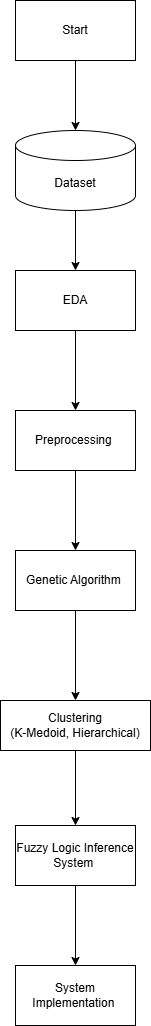

# Conclusion

This project presents a comprehensive data-driven approach to understanding customer behavior and value through the integration of data mining and intelligent systems.

**1. EDA  and Preprocessing:**
Data cleaning and feature engineering improved data quality and revealed important patterns in customer demographics and spending behavior.




**2. Feature Selection (Genetic Algorithm):**
The GA successfully identified the most relevant features (NumWebPurchases, Total_Spending, Is_Parent), reducing dimensionality while improving clustering performance.





**3. Customer Segmentation (Clustering):**
Customers were grouped into meaningful segments (e.g., Big Spenders, Budget Families, Web Shoppers), providing clear insights into different behavioral patterns.





**4. Customer Valuation (Fuzzy Logic):**
The fuzzy system assigned flexible value scores (VIP, Gold, Silver), enabling a more realistic evaluation of customer importance.




- **Business Value & Insights**
The analysis reveals that customers differ significantly in both behavior and value, requiring targeted strategies.
High-value customers contribute the most revenue and should be prioritized for retention.
Medium-value customers represent strong growth potential.
Low-value customers require cost-effective engagement strategies.


- **Recommended Actions**
Retention Strategy: Focus on VIP customers personalized offers and loyalty programs.
Growth Strategy: Convert medium-value customers into high-value through targeted marketing.
Engagement Strategy: Use discounts and promotions to activate low-value segments.
Digital Strategy: Leverage online channels for customers with high web engagement.

- **Final Insight**
By combining clustering (behavior analysis) with fuzzy logic (value evaluation), the project provides a complete understanding of customers, enabling businesses to make smarter, data-driven marketing decisions.